# It's a Metric, Too (Jane Street, October 2026)

The 11-by-11 region is subdivided into *states*: connected groups of squares that are symmetric under some rotation or reflection.
If every nontrivial rotation or reflection taking a state to itself fixes exactly one of its squares, that square is the state's *capitol*
(so a 1-by-3 bar and the X pentomino have no capitol).

Moving to an orthogonally adjacent square costs the size of the state you are in, or the smaller of the two sizes when crossing a border.
A number in a cell is the cheapest cost from that cell to any capitol.
Label every cell with the size of its state; the answer is the sum of the squares of the row sums.

In [1]:
import heapq
from collections import defaultdict

%matplotlib inline
import matplotlib.pyplot as plt

_ = None
CLUES = [
    [_, 8, 4, _, _, 11, _, _, _, 5, _],
    [_, _, _, _, _, _, _, 11, _, _, _],
    [_, _, 7, _, _, 1, _, _, _, _, 14],
    [28, _, _, 51, _, _, 1, _, 6, _, _],
    [_, 22, _, _, _, _, _, _, 4, _, 1],
    [_, _, _, 15, _, 10, _, 0, _, _, _],
    [11, _, 11, _, _, _, _, _, _, 9, _],
    [_, _, 17, _, 14, _, _, 10, _, _, 13],
    [30, _, _, _, _, 6, _, _, 45, _, _],
    [_, _, _, 10, _, _, _, _, _, _, _],
    [_, 26, _, _, _, 0, _, _, 77, 61, _],
]

## Solution

Each letter is one state.

In [2]:
SOLUTION = [
    "AAAABCDDDDD",
    "BBBBBCCCEEE",
    "BFFFFCGCEHE",
    "IFFFFCCCEHE",
    "IIFFFFJCKHH",
    "IFFFFFJJKHL",
    "IIIMFFFJJHH",
    "NNIMOFFFFFH",
    "NIIOOFFFFHH",
    "NNINOPFFFFH",
    "NNNNPPFFFFH",
]

## Verification

For every state: check connectivity, find all its symmetries (the 7 nontrivial isometries of the square lattice about the centre of its bounding box, which every symmetry must fix), and determine its capitol.
Then run Dijkstra from all capitols with the edge cost `min(size(u), size(v))` and compare with the clues.

In [3]:
ISOMETRIES = {
    "rot90": lambda y, x: (x, -y),
    "rot180": lambda y, x: (-y, -x),
    "rot270": lambda y, x: (-x, y),
    "mirror_row": lambda y, x: (-y, x),
    "mirror_col": lambda y, x: (y, -x),
    "mirror_diag": lambda y, x: (x, y),
    "mirror_anti": lambda y, x: (-x, -y),
}


def symmetries(cells):
    # map each symmetry to the list of cells it fixes; work in doubled coordinates around the bounding-box centre
    rows = [r for r, _ in cells]
    cols = [c for _, c in cells]
    pr, pc = min(rows) + max(rows), min(cols) + max(cols)
    found = {}
    for name, f in ISOMETRIES.items():
        image, fixed = set(), []
        for r, c in cells:
            y, x = f(2 * r - pr, 2 * c - pc)
            if (y + pr) % 2 or (x + pc) % 2:
                break
            img = ((y + pr) // 2, (x + pc) // 2)
            image.add(img)
            if img == (r, c):
                fixed.append(img)
        else:
            if image == set(cells):
                found[name] = fixed
    return found


def is_connected(cells):
    cells = set(cells)
    start = next(iter(cells))
    seen, stack = {start}, [start]
    while stack:
        r, c = stack.pop()
        for n in ((r + 1, c), (r - 1, c), (r, c + 1), (r, c - 1)):
            if n in cells and n not in seen:
                seen.add(n)
                stack.append(n)
    return len(seen) == len(cells)


states = defaultdict(list)
for r, row in enumerate(SOLUTION):
    for c, label in enumerate(row):
        states[label].append((r, c))

size, capitols = {}, []
for label, cells in sorted(states.items()):
    assert is_connected(cells), label
    syms = symmetries(cells)
    assert syms, f"state {label} is not symmetric"
    capitol = None
    if all(len(fixed) == 1 for fixed in syms.values()):
        (capitol,) = {fixed[0] for fixed in syms.values()}
        capitols.append(capitol)
    for cell in cells:
        size[cell] = len(cells)
    print(f"{label}: size {len(cells):2d}, symmetries {sorted(syms)}, capitol {capitol}")

A: size  4, symmetries ['mirror_col', 'mirror_row', 'rot180'], capitol None
B: size  7, symmetries ['rot180'], capitol (1, 2)
C: size 10, symmetries ['rot180'], capitol None
D: size  5, symmetries ['mirror_col', 'mirror_row', 'rot180'], capitol None
E: size  7, symmetries ['mirror_col'], capitol (1, 9)
F: size 37, symmetries ['rot180'], capitol (6, 5)
G: size  1, symmetries ['mirror_anti', 'mirror_col', 'mirror_diag', 'mirror_row', 'rot180', 'rot270', 'rot90'], capitol (2, 6)
H: size 12, symmetries ['rot180'], capitol None
I: size 11, symmetries ['rot180'], capitol (6, 1)
J: size  5, symmetries ['mirror_anti'], capitol (5, 7)
K: size  2, symmetries ['mirror_col', 'mirror_row', 'rot180'], capitol None
L: size  1, symmetries ['mirror_anti', 'mirror_col', 'mirror_diag', 'mirror_row', 'rot180', 'rot270', 'rot90'], capitol (5, 10)
M: size  2, symmetries ['mirror_col', 'mirror_row', 'rot180'], capitol None
N: size 10, symmetries ['mirror_anti'], capitol None
O: size  4, symmetries ['mirror_r

In [4]:
dist = {cell: float("inf") for cell in size}
heap = [(0, cap) for cap in capitols]
for cap in capitols:
    dist[cap] = 0
while heap:
    d, (r, c) = heapq.heappop(heap)
    if d > dist[(r, c)]:
        continue
    for n in ((r + 1, c), (r - 1, c), (r, c + 1), (r, c - 1)):
        if n in size and d + min(size[(r, c)], size[n]) < dist[n]:
            dist[n] = d + min(size[(r, c)], size[n])
            heapq.heappush(heap, (dist[n], n))

mismatches = [((r, c), v, dist[(r, c)]) for r, row in enumerate(CLUES) for c, v in enumerate(row)
              if v is not None and dist[(r, c)] != v]
print("clue mismatches:", mismatches)

for r in range(11):
    print(" ".join(f"{dist[(r, c)]:3d}" for c in range(11)))

clue mismatches: []
 12   8   4   8  12  11   6  11  10   5  10
 14   7   0   7  14  11   1  11   7   0   7
 21  14   7  14  11   1   0   1   8   7  14
 28  33  44  51  21  11   1  11   6  13   8
 33  22  33  52  48  11   6   5   4   6   1
 22  11  22  15  47  10   5   0   2   1   0
 11   0  11  13  15   0  10   5   4   9   1
 20  10  17  15  14  18  47  10   9  21  13
 30  20  18  14  10   6  43  47  45  33  25
 40  30  20  10   6   3   6  43  80  45  37
 36  26  16   6   3   0   3  40  77  61  49


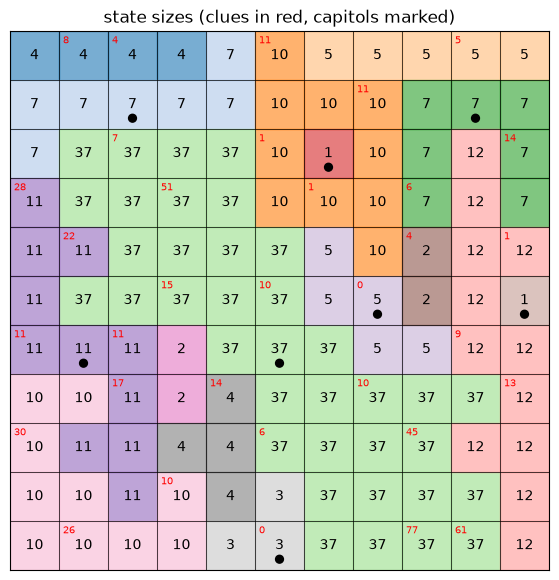

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
cmap = plt.get_cmap("tab20")
label_index = {label: i for i, label in enumerate(sorted(states))}
for (r, c), s in size.items():
    ax.add_patch(plt.Rectangle((c, r), 1, 1, color=cmap(label_index[SOLUTION[r][c]] % 20), alpha=0.6))
    ax.text(c + 0.5, r + 0.5, str(s), ha="center", va="center", fontsize=10)
    if CLUES[r][c] is not None:
        ax.text(c + 0.08, r + 0.1, str(CLUES[r][c]), ha="left", va="top", fontsize=7, color="red")
for r, c in capitols:
    ax.add_patch(plt.Circle((c + 0.5, r + 0.78), 0.08, color="black"))
ax.set_xlim(0, 11)
ax.set_ylim(11, 0)
ax.set_aspect("equal")
ax.set_xticks(range(12))
ax.set_yticks(range(12))
ax.grid(color="black", linewidth=0.5)
ax.tick_params(labelbottom=False, labelleft=False, length=0)
ax.set_title("state sizes (clues in red, capitols marked)")
plt.show()

In [6]:
row_sums = [sum(size[(r, c)] for c in range(11)) for r in range(11)]
print("row sums:", row_sums)
print("answer:", sum(s * s for s in row_sums))

row sums: [58, 86, 202, 215, 211, 221, 180, 234, 212, 208, 206]
answer: 408951


# Answer

$58^2 + 86^2 + 202^2 + 215^2 + 211^2 + 221^2 + 180^2 + 234^2 + 212^2 + 208^2 + 206^2 = 408951$

*How it was found:* the clue arithmetic forces several huge states (e.g. 51 at (3,3) and 77/61/45 in the bottom right), which defeats plain enumeration of polyomino shapes.
The solution came from an exact CP-SAT model in which small states (up to 8 cells) are drawn from a library of symmetric polyominoes, while each large state picks one of the 525 lattice involutions (reflections and half-turns) it must be invariant under.
Distances are pinned to true shortest-path values by Bellman inequalities plus witnesses.
A case split on which square next to the 1-clues at (2,5) and (3,6) is a single-square state ruled out every configuration with a 50-cell state, and the solution above is the one found in the remaining case.

*Uniqueness:* every branch of that case split was searched to completion (with the found size labelling forbidden in the branch that contains it) and none has another solution, so the size labelling above, and hence the answer, is unique.